In [12]:
%pip install kagglehub python-dotenv

import os
from dotenv import load_dotenv
import kagglehub

load_dotenv()

if not os.getenv("KAGGLE_API_TOKEN"):
    raise RuntimeError("KAGGLE_API_TOKEN is not set. Add it to .env or set it in your environment.")

# Download latest version
path = kagglehub.dataset_download("davidcariboo/player-scores")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: /Users/koenamukherjee/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/677


In [5]:
pip install pandas scikit-learn matplotlib seaborn jupyter

  Using cached pandas-3.0.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.5.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1

In [6]:
import pandas as pd

print(os.listdir(path))

['game_lineups.csv', 'competitions.csv', 'appearances.csv', 'countries.csv', 'player_valuations.csv', 'game_events.csv', 'transfers.csv', 'players.csv', 'games.csv', 'club_games.csv', 'national_teams.csv', 'clubs.csv']


In [8]:
df = pd.read_csv(os.path.join(path, "players.csv"))

In [10]:
columns_to_keep = ['name', 'position', 'market_value_in_eur', 'current_club_name']

df_filtered = df[columns_to_keep]

df_clean = df_filtered.dropna(subset=['market_value_in_eur'])

df_sorted = df_clean.sort_values(by='market_value_in_eur', ascending=False)

top_10 = df_sorted.head(10)

In [11]:
print("--- TOP 10 MOST VALUABLE PLAYERS ---")
print(top_10.to_string(index=False))

--- TOP 10 MOST VALUABLE PLAYERS ---
                 name position  market_value_in_eur   current_club_name
         Lamine Yamal   Attack          200000000.0        FC Barcelona
       Erling Haaland   Attack          200000000.0     Manchester City
        Kylian Mbappé   Attack          180000000.0         Real Madrid
                Pedri Midfield          150000000.0        FC Barcelona
        Michael Olise   Attack          150000000.0       Bayern Munich
              Vitinha Midfield          140000000.0 Paris Saint-Germain
Khvicha Kvaratskhelia   Attack          140000000.0 Paris Saint-Germain
      Vinicius Junior   Attack          140000000.0         Real Madrid
           João Neves Midfield          140000000.0 Paris Saint-Germain
      Jude Bellingham Midfield          130000000.0         Real Madrid


In [19]:
## age vs. market value (hyp: younger players are more valuable)

columns_to_analyze = ['name', 'date_of_birth', 'market_value_in_eur', 'position']
df_clean = df[columns_to_analyze].dropna()

# 3. Convert birth dates to datetime objects
df_clean['date_of_birth'] = pd.to_datetime(df_clean['date_of_birth'])

# 4. Calculate integer age using 2026 as the baseline year
df_clean['age'] = (2026 - df_clean['date_of_birth'].dt.year).astype(int)

# 5. Extract, isolate, and format the top 10 most valuable players
top_10 = df_clean.sort_values(by='market_value_in_eur', ascending=False).head(10).copy()
top_10['market_value_m'] = top_10['market_value_in_eur'] / 1_000_000
top_10 = top_10.reset_index(drop=True)

# 6. Print the finalized data table to the terminal
print("--- TOP 10 PLAYERS BY AGE & VALUE ---")
print(top_10[['name', 'age', 'market_value_m', 'position']].to_string(index=False))

--- TOP 10 PLAYERS BY AGE & VALUE ---
                 name  age  market_value_m position
       Erling Haaland   26           200.0   Attack
         Lamine Yamal   19           200.0   Attack
        Kylian Mbappé   28           180.0   Attack
        Michael Olise   25           150.0   Attack
                Pedri   24           150.0 Midfield
              Vitinha   26           140.0 Midfield
           João Neves   22           140.0 Midfield
Khvicha Kvaratskhelia   25           140.0   Attack
      Vinicius Junior   26           140.0   Attack
      Jude Bellingham   23           130.0 Midfield


findfont: Failed to find font weight semibold, now using 700.


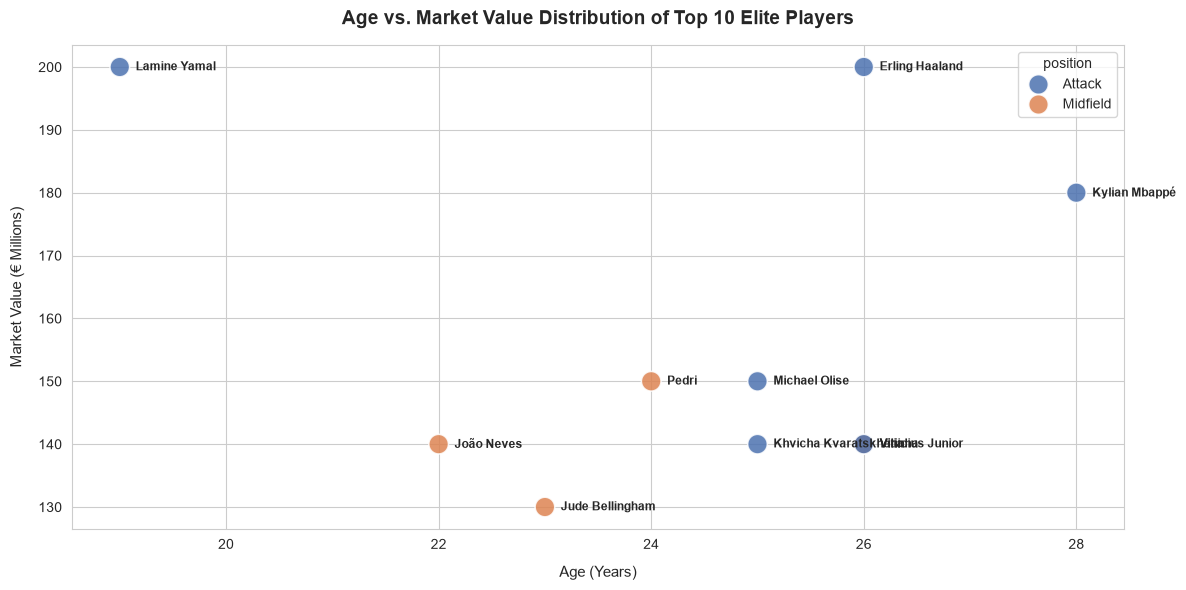

In [20]:
## plotting 

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

## scatter plot
ax = sns.scatterplot(
  data=top_10,
  x='age',
  y='market_value_m',
  hue='position',
  s=200, # marker size
  palette='deep',
  alpha=0.85 # transparency
)

## labels
for idx, row in top_10.iterrows():
  ax.text(
    x=row['age'] + 0.15,         # Shift slightly right of the dot
    y=row['market_value_m'],     # Keep vertical level the same
    s=row['name'],               # The text to display
    horizontalalignment='left',
    size='small',
    verticalalignment='center',
    weight='semibold'
  )

## title
plt.title('Age vs. Market Value Distribution of Top 10 Elite Players', fontsize=14, pad=15, weight='bold')
plt.xlabel('Age (Years)', fontsize=11, labelpad=10)
plt.ylabel('Market Value (€ Millions)', fontsize=11, labelpad=10)

# Clean up layout and display the window
plt.tight_layout()
plt.show()

there is probably a trend between the midfileders. i feel like yamal is an outlier. and haaland is probably the top of the normal distribution.

In [21]:
## --- PROVING THE HYPOTHESIS ---

print("\n--- POSITION-WIDE MARKET STANDARDS ---")
# 1. Group the entire dataset by position to see the overall reality
position_stats = df.groupby('position').agg(
    average_value_m=('market_value_in_eur', lambda x: x.mean() / 1_000_000),
    median_age=('date_of_birth', lambda x: 2026 - pd.to_datetime(x).dt.year.median()),
    player_count=('name', 'count')
).reset_index()

print(position_stats.to_string(index=False))


--- POSITION-WIDE MARKET STANDARDS ---
  position  average_value_m  median_age  player_count
    Attack         1.807509        28.0         13502
  Defender         1.406029        29.0         15961
Goalkeeper         0.712464        28.0          5828
  Midfield         1.668365        28.0         14272
   Missing         0.150853        21.0           586


Mbappe valuations to compare with Yamal's timeline.

In [27]:
import os
print(os.listdir('.'))


['.gitignore', '.venv', '.github', '.env.example', '.git', 'analysis.ipynb']


In [28]:
## finding Mbappe's player ID
# Use the dataset directory returned by kagglehub, not the notebook working directory
if 'path' not in globals() or not os.path.isdir(path):
    raise FileNotFoundError("Dataset path not found. Run the Kaggle download cell first.")

data_dir = path
players_path = os.path.join(data_dir, 'players.csv')
valuations_path = os.path.join(data_dir, 'player_valuations.csv')

if not os.path.exists(players_path):
    raise FileNotFoundError(f"Could not find players.csv in {data_dir}")
if not os.path.exists(valuations_path):
    raise FileNotFoundError(f"Could not find player_valuations.csv in {data_dir}")

df_players = pd.read_csv(players_path)
df_valuations = pd.read_csv(valuations_path)

# 2. Find Mbappe's unique player ID (using case-insensitive matching)
mbappe_row = df_players[df_players['name'].str.contains('Mbappé|Mbappe', case=False, na=False)]

if mbappe_row.empty:
    raise ValueError("Mbappé/Mbappe not found in players.csv. Check the dataset contents.")

mbappe_id = mbappe_row['player_id'].iat[0]
mbappe_dob = pd.to_datetime(mbappe_row['date_of_birth'].iat[0])

print(f"Found Player: {mbappe_row['name'].iat[0]} (ID: {mbappe_id})")


Found Player: Kylian Mbappé (ID: 342229)


In [30]:
## --- EXTRACT MBAPPÉ'S HISTORICAL PROGRESSION ---

# 1. Filter for Mbappe's valuation history using the ID you found
mbappe_history = df_valuations[df_valuations['player_id'] == mbappe_id].copy()

if mbappe_history.empty:
    raise ValueError(f"No valuation history found for player_id {mbappe_id}.")

# 2. Parse dates and sort chronologically
mbappe_history['date'] = pd.to_datetime(mbappe_history['date'])
mbappe_history = mbappe_history.sort_values(by='date').reset_index(drop=True)

# 3. Calculate his exact age at the time of each historical valuation
# mbappe_dob is a single Timestamp, not a one-element Series
birth_year = mbappe_dob.year
mbappe_history['historical_age'] = (mbappe_history['date'].dt.year - birth_year).astype(int)

# 4. Convert the valuation column into easily readable Millions (€M)
mbappe_history['market_value_m'] = mbappe_history['market_value_in_eur'] / 1_000_000

# 5. Drop multiple updates within the same year to keep the summary crisp
# This keeps his peak valuation achieved for each single year of his life
age_progression = mbappe_history.drop_duplicates(subset=['historical_age'], keep='last')

# 6. Print the summary table
print("--- MBAPPÉ MARKET VALUE PROGRESSION BY AGE ---")
print(age_progression[['date', 'historical_age', 'market_value_m']].to_string(index=False))


--- MBAPPÉ MARKET VALUE PROGRESSION BY AGE ---
      date  historical_age  market_value_m
2015-12-02              17            0.05
2016-11-01              18            4.00
2017-10-12              19           90.00
2018-12-17              20          200.00
2019-12-19              21          200.00
2020-10-15              22          180.00
2021-12-16              23          160.00
2022-12-23              24          180.00
2023-12-18              25          180.00
2024-12-27              26          160.00
2025-12-12              27          200.00
2026-06-05              28          180.00


some notes:
- age 18 to 19: champions league in monaco and move to PSG (exponential growth)
- what happened in 2021?

Found Player: Lamine Yamal (ID: 937958)
--- YAMAL MARKET VALUE PROGRESSION BY AGE ---
      date  historical_age  market_value_m
2023-12-22              16            60.0
2024-12-27              17           180.0
2025-12-12              18           200.0
2026-06-05              19           200.0
--- COMPARISON TABLE: MESSI / RONALDO / NEYMAR / MBAPPÉ / YAMAL ---
 historical_age  market_value_m  player
             17            0.05  Mbappé
             18            4.00  Mbappé
             19           90.00  Mbappé
             20          200.00  Mbappé
             21          200.00  Mbappé
             22          180.00  Mbappé
             23          160.00  Mbappé
             24          180.00  Mbappé
             25          180.00  Mbappé
             26          160.00  Mbappé
             27          200.00  Mbappé
             28          180.00  Mbappé
             16           60.00   Yamal
             17          180.00   Yamal
             18          200.00

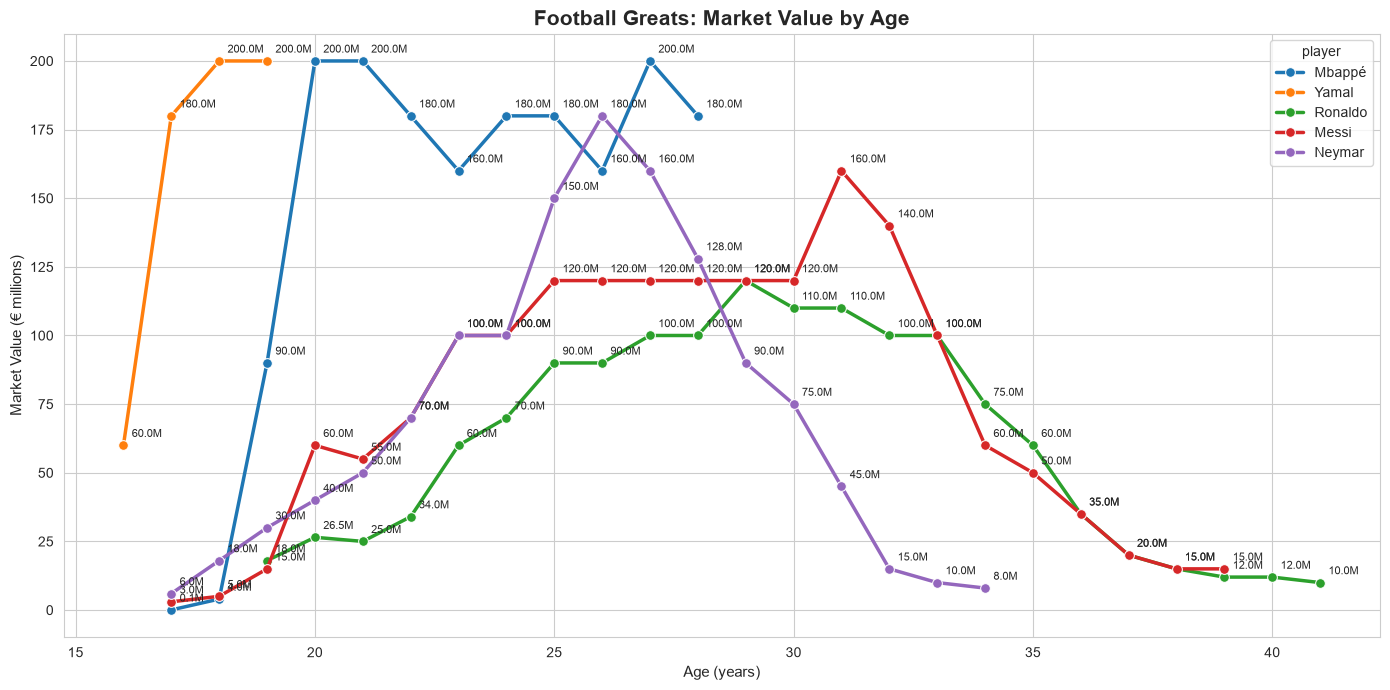

In [32]:
## FINDING YAMAL'S HISTORICAL PROGRESSION
# 1. Find Yamal in the player table
yamal_row = df_players[df_players['name'].str.contains('Yamal|Lamine Yamal', case=False, na=False)]

if yamal_row.empty:
    raise ValueError("Yamal not found in players.csv. Check the dataset contents.")

yamal_id = yamal_row['player_id'].iat[0]
yamal_dob = pd.to_datetime(yamal_row['date_of_birth'].iat[0])
print(f"Found Player: {yamal_row['name'].iat[0]} (ID: {yamal_id})")

# 2. Filter and prepare Yamal's valuation history
yamal_history = df_valuations[df_valuations['player_id'] == yamal_id].copy()

if yamal_history.empty:
    raise ValueError(f"No valuation history found for player_id {yamal_id}.")

yamal_history['date'] = pd.to_datetime(yamal_history['date'])
yamal_history = yamal_history.sort_values(by='date').reset_index(drop=True)

yamal_history['historical_age'] = (yamal_history['date'].dt.year - yamal_dob.year).astype(int)
yamal_history['market_value_m'] = yamal_history['market_value_in_eur'] / 1_000_000
yamal_progression = yamal_history.drop_duplicates(subset=['historical_age'], keep='last')

print("--- YAMAL MARKET VALUE PROGRESSION BY AGE ---")
print(yamal_progression[['date', 'historical_age', 'market_value_m']].to_string(index=False))

# 3. Prepare the player comparison dataset
player_names = {
    'Mbappé': mbappe_id,
    'Yamal': yamal_id,
    'Ronaldo': None,
    'Messi': None,
    'Neymar': None,
}

# Helper to build progression for any player by name lookup

def build_player_progression(player_label, player_name_pattern):
    name_row = df_players[df_players['name'].str.contains(player_name_pattern, case=False, na=False)]
    if name_row.empty:
        raise ValueError(f"{player_label} not found in players.csv. Check the dataset contents.")
    pid = name_row['player_id'].iat[0]
    dob = pd.to_datetime(name_row['date_of_birth'].iat[0])

    history = df_valuations[df_valuations['player_id'] == pid].copy()
    if history.empty:
        raise ValueError(f"No valuation history found for {player_label} (player_id {pid}).")

    history['date'] = pd.to_datetime(history['date'])
    history = history.sort_values(by='date').reset_index(drop=True)
    history['historical_age'] = (history['date'].dt.year - dob.year).astype(int)
    history['market_value_m'] = history['market_value_in_eur'] / 1_000_000
    progression = history.drop_duplicates(subset=['historical_age'], keep='last')
    return progression.assign(player=player_label)

mbappe_comp = age_progression[['historical_age', 'market_value_m']].copy().assign(player='Mbappé')
yamal_comp = yamal_progression[['historical_age', 'market_value_m']].copy().assign(player='Yamal')
ronaldo_comp = build_player_progression('Ronaldo', 'Ronaldo|Cristiano Ronaldo')
neymar_comp = build_player_progression('Neymar', 'Neymar|Neymar Jr|Neymar Junior')
messi_comp = build_player_progression('Messi', 'Messi|Lionel Messi')

comparison_df = pd.concat([
    mbappe_comp,
    yamal_comp,
    ronaldo_comp[['historical_age', 'market_value_m', 'player']],
    messi_comp[['historical_age', 'market_value_m', 'player']],
    neymar_comp[['historical_age', 'market_value_m', 'player']],
], ignore_index=True)

print("--- COMPARISON TABLE: MESSI / RONALDO / NEYMAR / MBAPPÉ / YAMAL ---")
print(comparison_df.to_string(index=False))

# 4. Plot the comparison for five players
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=comparison_df,
    x='historical_age',
    y='market_value_m',
    hue='player',
    marker='o',
    linewidth=2.5,
    markersize=7,
    sort=False
)

for player_name, group in comparison_df.groupby('player'):
    for _, row in group.iterrows():
        ax.annotate(
            f'{row["market_value_m"]:.1f}M',
            (row['historical_age'], row['market_value_m']),
            textcoords='offset points',
            xytext=(6, 6),
            fontsize=8
        )

plt.title('Football Greats: Market Value by Age', fontsize=15, weight='bold')
plt.xlabel('Age (years)', fontsize=11)
plt.ylabel('Market Value (€ millions)', fontsize=11)
plt.tight_layout()
plt.show()


In [14]:
## position data (hyp: forwards cost more since they are crucial for scoring goals)

# Group the entire dataset by position and find the average market value
position_value = df.groupby('position')['market_value_in_eur'].mean().reset_index()

# Sort by highest average value to see which position is the most expensive
print(position_value.sort_values(by='market_value_in_eur', ascending=False))

     position  market_value_in_eur
0      Attack         1.807509e+06
3    Midfield         1.668365e+06
1    Defender         1.406029e+06
2  Goalkeeper         7.124642e+05
4     Missing         1.508527e+05


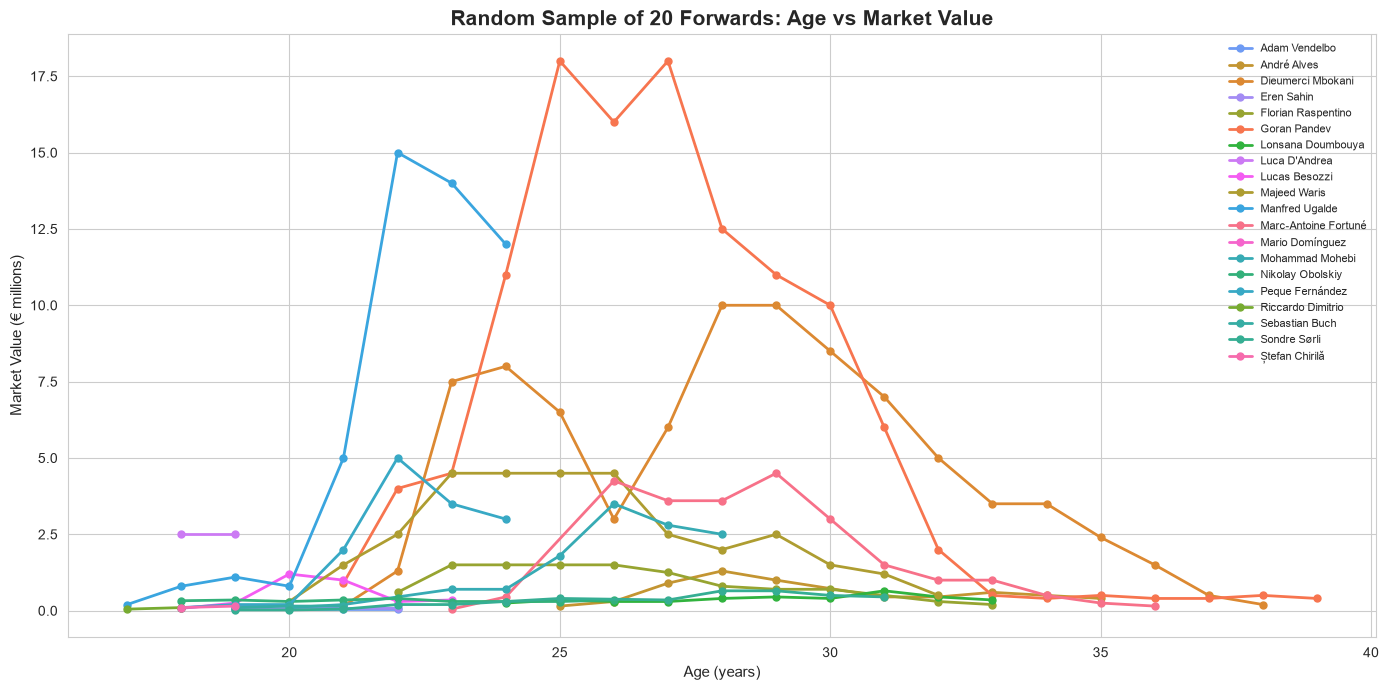

In [37]:
## RANDOM SAMPLE OF 20 FORWARDS
# Build a general market-value-by-age sample limited to forwards only
position_series = df_players['position'].fillna('').astype(str).str.lower()
forward_mask = position_series.str.contains(
    r'forward|fw|striker|centre-forward|center-forward|cf|st|winger|second striker|attack',
    regex=True
)
forward_players = df_players.loc[forward_mask].copy()
forward_players = forward_players.dropna(subset=['date_of_birth']).copy()

if forward_players.empty:
    raise ValueError('No forward players were found in the dataset.')

# Only include players with valuation history, otherwise the plot will be empty
forward_players = forward_players[forward_players['player_id'].isin(df_valuations['player_id'])].copy()
if forward_players.empty:
    raise ValueError('No forwards have valuation history in the dataset.')

sample_n = min(20, len(forward_players))
forward_players = forward_players.sample(n=sample_n, random_state=42).copy()
forward_players['date_of_birth'] = pd.to_datetime(forward_players['date_of_birth'])

sample_ids = forward_players['player_id'].tolist()
random_history = df_valuations[df_valuations['player_id'].isin(sample_ids)].copy()

if random_history.empty:
    raise ValueError('No historical valuations found for the sampled forwards.')

random_history['date'] = pd.to_datetime(random_history['date'])
random_history = random_history.sort_values(['player_id', 'date']).reset_index(drop=True)

random_history = random_history.merge(
    forward_players[['player_id', 'name', 'date_of_birth']],
    on='player_id',
    how='left'
)

random_history['historical_age'] = (random_history['date'].dt.year - random_history['date_of_birth'].dt.year).astype(int)
random_history['market_value_m'] = random_history['market_value_in_eur'] / 1_000_000

# Keep one valuation per age per player for a cleaner overview
random_progression = random_history.drop_duplicates(subset=['player_id', 'historical_age'], keep='last').copy()

# Plot one clean trend line per player, color-coded by player
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

palette = sns.color_palette('husl', n_colors=len(random_progression['name'].unique()))
player_colors = dict(zip(random_progression['name'].unique(), palette))

for player_name, group in random_progression.groupby('name'):
    group = group.sort_values('historical_age')
    if len(group) >= 2:
        plt.plot(
            group['historical_age'],
            group['market_value_m'],
            marker='o',
            linewidth=2,
            markersize=5,
            label=player_name,
            color=player_colors[player_name]
        )

plt.title('Random Sample of 20 Forwards: Age vs Market Value', fontsize=15, weight='bold')
plt.xlabel('Age (years)', fontsize=11)
plt.ylabel('Market Value (€ millions)', fontsize=11)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


/var/folders/qx/gf__whpd43sgc1rvvzjcxdzr0000gn/T/ipykernel_89103/2809951587.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


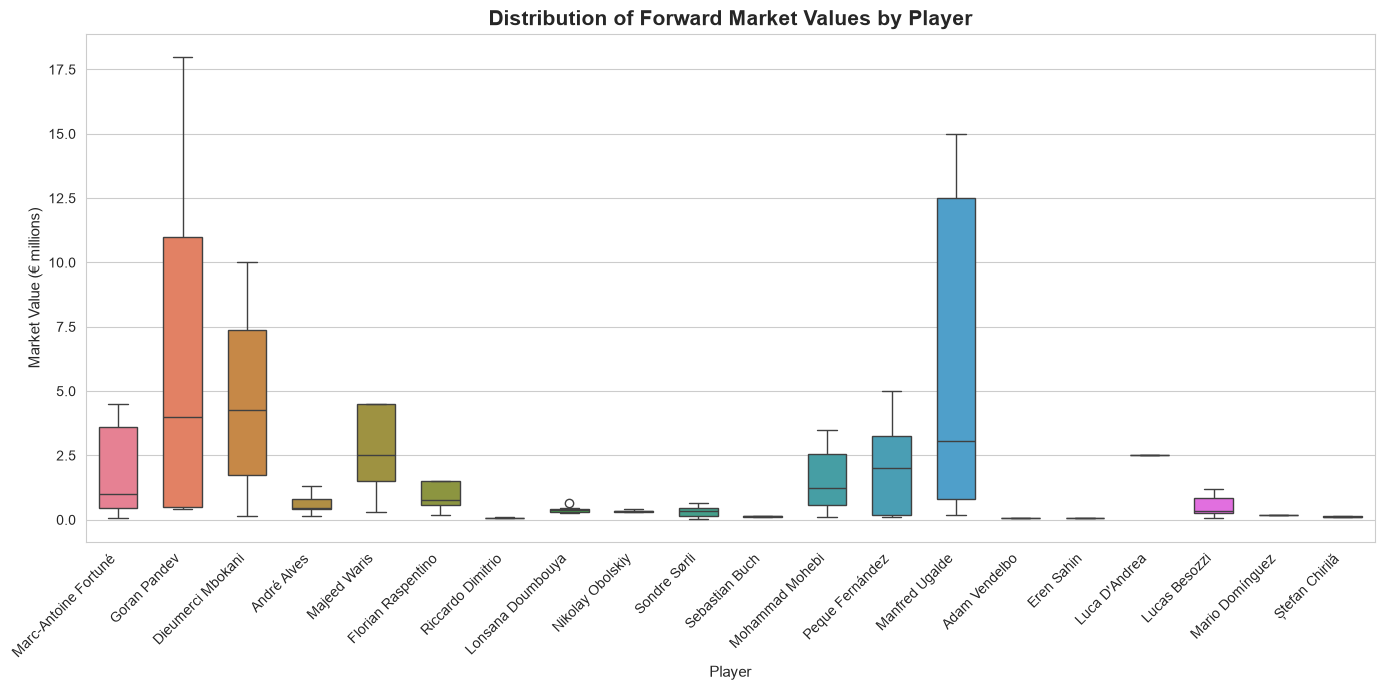

/var/folders/qx/gf__whpd43sgc1rvvzjcxdzr0000gn/T/ipykernel_89103/2809951587.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


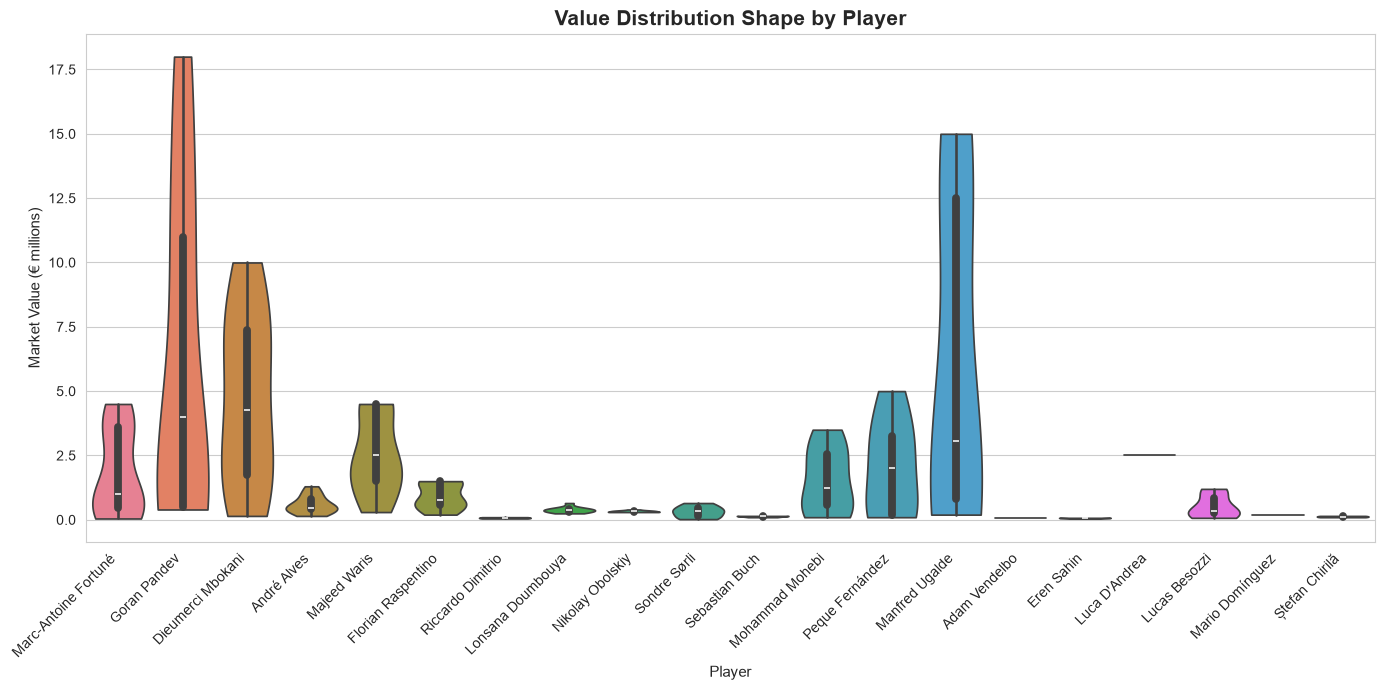

In [38]:
## DISTRIBUTION VIEW FOR FORWARD MARKET VALUES
# Use a distribution chart to summarize the overall spread of valuations
# among the sampled forwards.

sample_value_distribution = random_progression[['name', 'market_value_m']].copy()

# For a cleaner distribution summary, plot a boxplot of valuations by player
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=sample_value_distribution,
    x='name',
    y='market_value_m',
    palette='husl',
    width=0.6
)

plt.title('Distribution of Forward Market Values by Player', fontsize=15, weight='bold')
plt.xlabel('Player', fontsize=11)
plt.ylabel('Market Value (€ millions)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optional: a violin plot is also useful if you want a smoother sense of spread
plt.figure(figsize=(14, 7))
sns.violinplot(
    data=sample_value_distribution,
    x='name',
    y='market_value_m',
    palette='husl',
    cut=0
)
plt.title('Value Distribution Shape by Player', fontsize=15, weight='bold')
plt.xlabel('Player', fontsize=11)
plt.ylabel('Market Value (€ millions)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [41]:
from scipy import stats

# Use the sampled forward valuations, not the full player dataframe
values = random_progression['market_value_m'].dropna()

if len(values) < 3:
    raise ValueError('Not enough values to test distribution shape reliably.')

# 1. Calculate skewness
skew = values.skew()
print(f"Skewness: {skew:.3f}")
print("-> Interpretation: " + ("Fairly symmetrical" if abs(skew) < 0.5 else "Highly skewed"))

# 2. Run Shapiro-Wilk Normality Test
shapiro_stat, p_value = stats.shapiro(values)
print(f"\nShapiro-Wilk Test p-value: {p_value:.5f}")

if p_value > 0.05:
    print("Result: Fail to reject the null hypothesis. The sampled forward values are consistent with a normal distribution.")
else:
    print("Result: Reject the null hypothesis. The sampled forward values are not normally distributed.")


Skewness: 2.502
-> Interpretation: Highly skewed

Shapiro-Wilk Test p-value: 0.00000
Result: Reject the null hypothesis. The sampled forward values are not normally distributed.


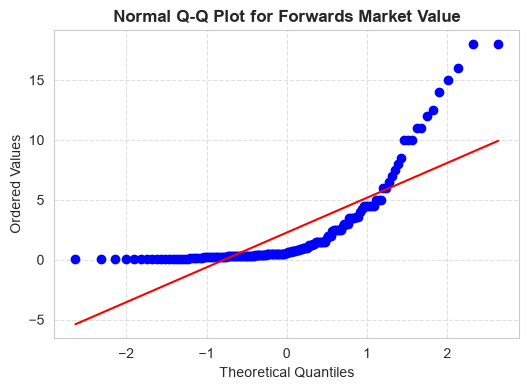

In [49]:
import matplotlib.pyplot as plt

if len(values) < 3:
    raise ValueError('Not enough values to draw a Q-Q plot reliably.')

plt.figure(figsize=(6, 4))

# Fix: Change 'normal' to 'norm'
stats.probplot(values, dist='norm', plot=plt)

plt.title('Normal Q-Q Plot for Forwards Market Value', fontsize=12, weight='bold')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


hypothesized a normal distribution. not normal, maybe log transformation.

--- SKEWNESS COMPARISON ---
Original Data Skewness:   2.502 (Highly skewed)
Log-Transformed Skewness: 1.113 (Target: close to 0 for symmetry)


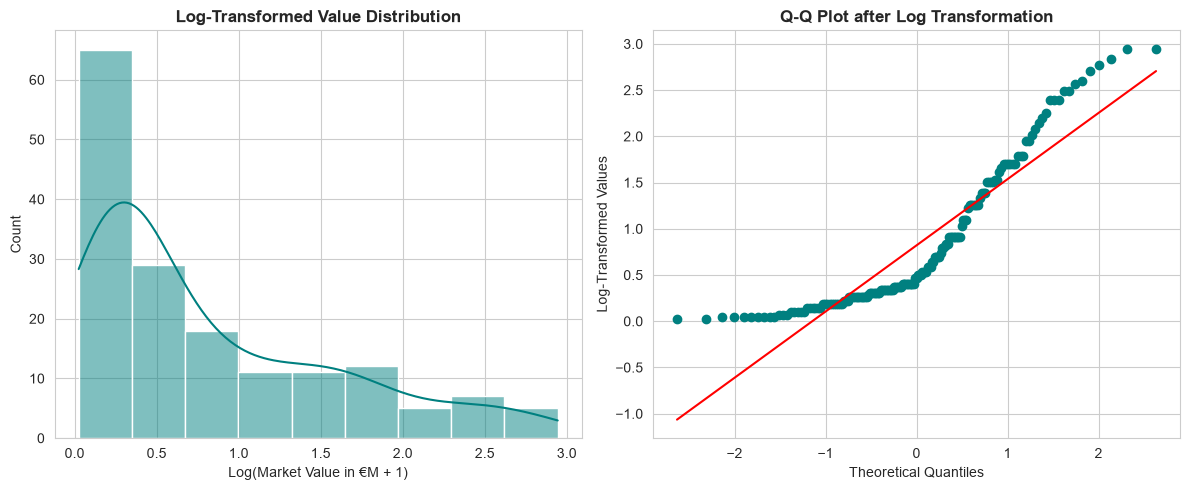

In [48]:
# 1. Apply log transformation (we use log1p, which handles any potential 0 values safely)
transformed_values = np.log1p(random_progression['market_value_m'].dropna())

# 2. Check the new skewness score
original_skew = random_progression['market_value_m'].dropna().skew()
new_skew = transformed_values.skew()

print("--- SKEWNESS COMPARISON ---")
print(f"Original Data Skewness:   {original_skew:.3f} (Highly skewed)")
print(f"Log-Transformed Skewness: {new_skew:.3f} (Target: close to 0 for symmetry)")

# 3. Plot the new Q-Q Plot side-by-side with a Histogram to verify normality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: The new normal distribution histogram
sns.histplot(transformed_values, kde=True, ax=ax1, color='teal')
ax1.set_title('Log-Transformed Value Distribution', weight='bold')
ax1.set_xlabel('Log(Market Value in €M + 1)')

# Right plot: The new Q-Q plot
stats.probplot(transformed_values, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot after Log Transformation', weight='bold')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Log-Transformed Values')
ax2.get_lines()[0].set_color('teal') # match the theme

plt.tight_layout()
plt.show()


--- ACTIVE MARKET SKEWNESS (Players > €1M) ---
Original Filtered Skewness:   3.085
Log-Transformed Active Skew:  1.443 (Aiming for close to 0)


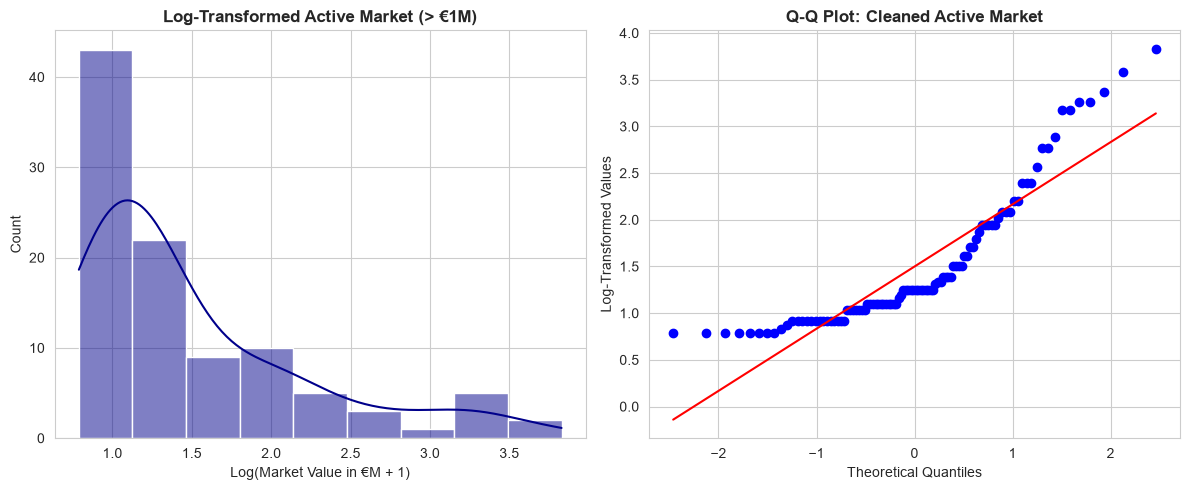

In [51]:
# 1. Filter out the noise: Keep only players worth MORE than €1 Million
# (Change 'df' to match your master dataframe if needed)
active_market = df[df['market_value_in_eur'] > 1_000_000].copy()

# 2. Re-calculate market value in Millions
active_market['market_value_m'] = active_market['market_value_in_eur'] / 1_000_000

# 3. Take a clean, random sample of 100 players from this active professional tier
# We use a larger sample size (100) now to get a smoother distribution curve
active_sample = active_market.sample(n=100, random_state=42)
active_values = active_sample['market_value_m']

# 4. Apply the Log Transformation to our filtered active values
log_active_values = np.log1p(active_values)

# 5. Measure Skewness
orig_active_skew = active_values.skew()
transformed_active_skew = log_active_values.skew()

print("--- ACTIVE MARKET SKEWNESS (Players > €1M) ---")
print(f"Original Filtered Skewness:   {orig_active_skew:.3f}")
print(f"Log-Transformed Active Skew:  {transformed_active_skew:.3f} (Aiming for close to 0)")

# 6. Plot the clean, filtered distributions side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Filtered Histogram
sns.histplot(log_active_values, kde=True, ax=ax1, color='darkblue')
ax1.set_title('Log-Transformed Active Market (> €1M)', weight='bold')
ax1.set_xlabel('Log(Market Value in €M + 1)')

# Right Plot: Filtered Q-Q Plot
stats.probplot(log_active_values, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot: Cleaned Active Market', weight='bold')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Log-Transformed Values')

plt.tight_layout()
plt.show()


insights: appears to be Pareto distribution. "A Pareto distribution is a power-law probability distribution where a small portion of items or events accounts for the majority of the total effect or value." [UC Berkeley](https://dlab.berkeley.edu/news/explaining-80-20-rule-pareto-distribution)
majority of pros are valued around 1mil euros because most are bench players, younger players or lower-valued starters. We see fewer higher-valued players who are exceptional (like mbappe, haaland).